/Users/deweywang/Desktop/GitHub整理/OmicsFlow/1. OmicsML/utils/data_processing.py:226: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_for_pca = data_for_pca.fillna(data_for_pca.loc['Mean'])


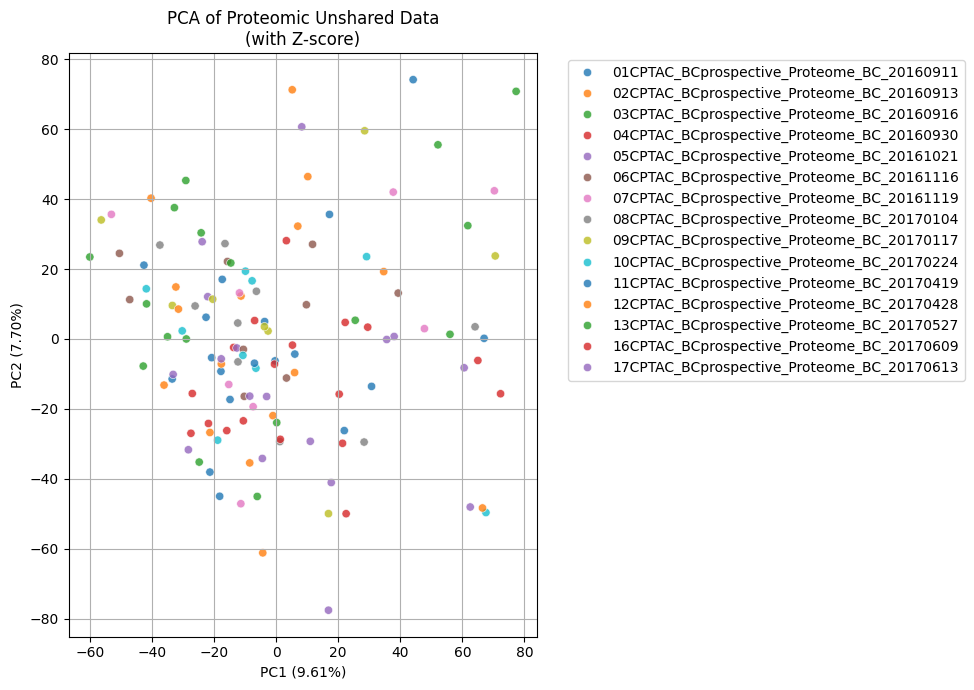

/Users/deweywang/Desktop/GitHub整理/OmicsFlow/1. OmicsML/utils/data_processing.py:226: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_for_pca = data_for_pca.fillna(data_for_pca.loc['Mean'])


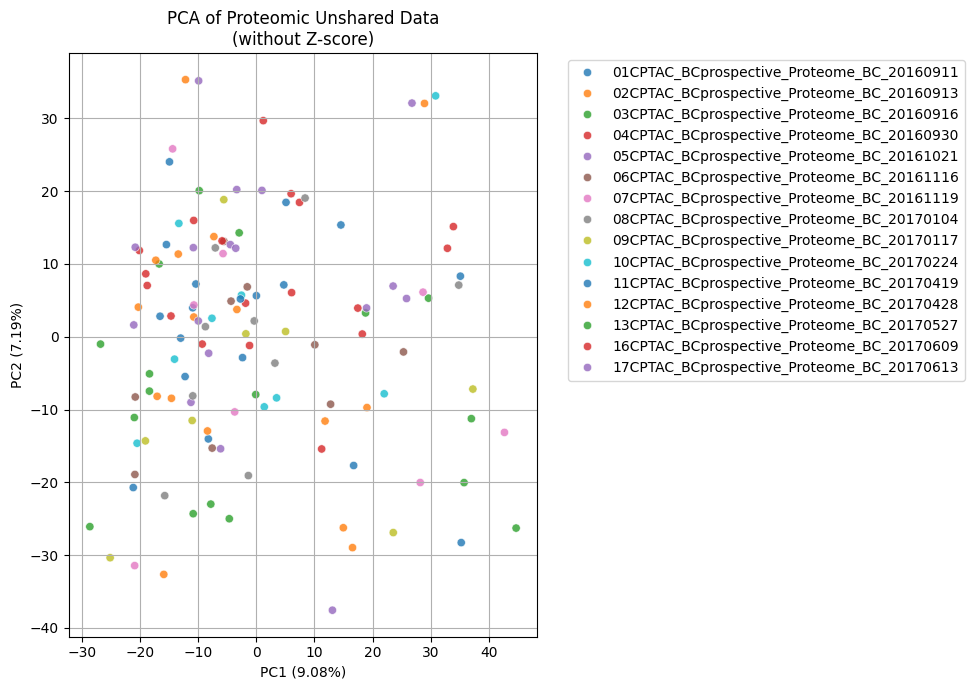

/opt/anaconda3/envs/OmicsFlow/lib/python3.9/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/envs/OmicsFlow/lib/python3.9/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/envs/OmicsFlow/lib/python3.9/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


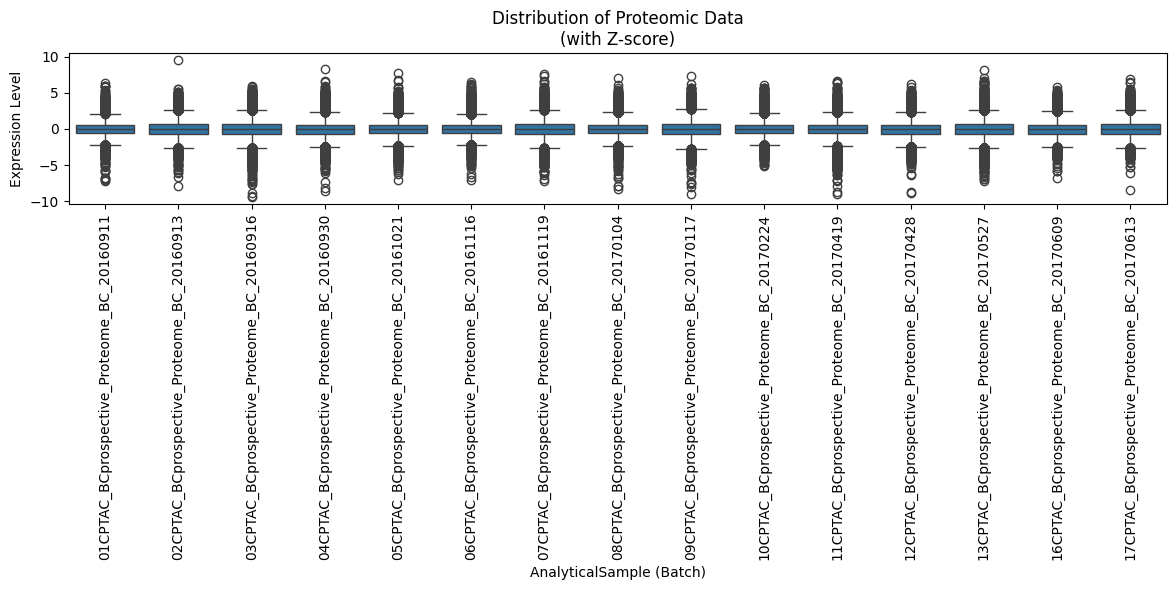

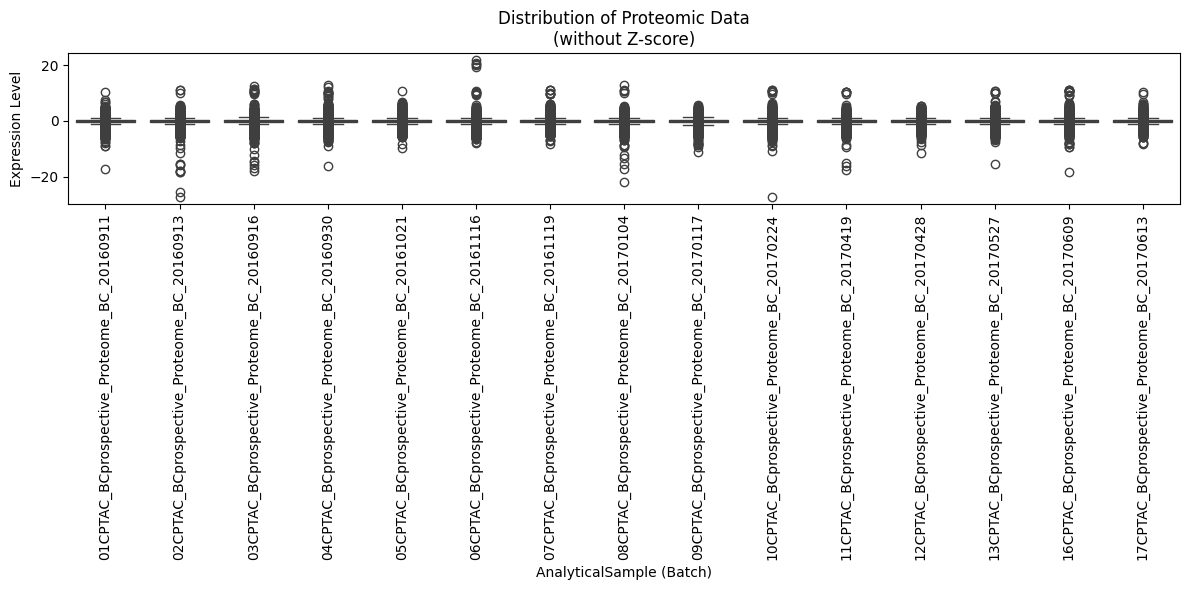

✅ Duplicate samples have been merged and saved as:
📂 dataset/processed/1. Data_preparation-matching_ID/Proteome/Proteomic_log_merged.csv
📂 dataset/processed/1. Data_preparation-matching_ID/Proteome/Proteomic_unshared_merged.csv
✅ RNA-seq file mapping has been saved to:
📂 dataset/processed/1. Data_preparation-matching_ID/RNA-seq/rna_seq_file_mapping.csv


In [1]:
from utils.data_processing import *

# Set output directory
output_dir = "./dataset/processed/1. Data_preparation-matching_ID/Proteome/"
ensure_directory(output_dir)

# Load data
gdc_df = load_and_clean_dataframe("./dataset/CPTAC/RNA-Seq/gdc_sample_sheet.2025-02-14.tsv", sep="\t")
pdc_df = load_and_clean_dataframe("./dataset/CPTAC/Proteomics/Primary_tumor/PDC_biospecimen_manifest_02152025_021616.tsv", sep="\t")

# Find matched samples
matched_samples, proteomics_only, rna_seq_only = find_matched_samples(gdc_df, pdc_df)

# Create matched_df (dataframe containing matched samples)
matched_df = pdc_df[pdc_df["Case Submitter ID"].astype(str).isin(matched_samples)]

# Process proteomics data
proteomic_df = load_and_clean_dataframe("./dataset/CPTAC/Proteomics/Primary_tumor/protein assembly/CPTAC2_Breast_Prospective_Collection_BI_Proteome.tmt10.tsv", sep="\t")
metadata_df = pd.read_csv("./dataset/processed/1. Data_preparation-matching_ID/Proteome/CPTAC2_Breast_Proteome_sample_modified.tsv", sep="\t")

log_df, unshared_df = process_proteomics_data(proteomic_df, matched_df, metadata_df, output_dir)

# Perform PCA analysis
perform_pca_analysis(unshared_df, "PCA of Proteomic Unshared Data")
perform_pca_analysis(unshared_df, "PCA of Proteomic Unshared Data", False)

# With Z-score normalization (default)
plot_expression_boxplot(unshared_df, "Distribution of Proteomic Data")

# Without Z-score normalization
plot_expression_boxplot(unshared_df, "Distribution of Proteomic Data", perform_zscore=False)

# Merge duplicate samples
duplic_ids = set(pd.read_csv(f"{output_dir}/aliquot_ids_with_multiple_matches.csv")["Aliquot Submitter ID"])
merged_log_df = merge_duplicate_samples(log_df, duplic_ids) 
merged_unshared_df = merge_duplicate_samples(unshared_df, duplic_ids) 

# Save the processed DataFrames
merged_log_df.to_csv("dataset/processed/1. Data_preparation-matching_ID/Proteome/Proteomic_log_merged.csv")
merged_unshared_df.to_csv("dataset/processed/1. Data_preparation-matching_ID/Proteome/Proteomic_unshared_merged.csv")

print("✅ Duplicate samples have been merged and saved as:")
print("📂 dataset/processed/1. Data_preparation-matching_ID/Proteome/Proteomic_log_merged.csv")
print("📂 dataset/processed/1. Data_preparation-matching_ID/Proteome/Proteomic_unshared_merged.csv")


# 準備 RNA-seq 文件映射
case_to_file_df = create_case_to_file_mapping(
    matched_samples_path="dataset/processed/1. Data_preparation-matching_ID/Proteome/matched_samples_with_aliquot.csv",
    gdc_sample_sheet_path="dataset/CPTAC/RNA-Seq/gdc_sample_sheet.2025-02-14.tsv",
    output_dir="dataset/processed/1. Data_preparation-matching_ID/RNA-seq"
)

In [2]:
!python scripts/download_rna_seq.py \
    --case-file "dataset/processed/1. Data_preparation-matching_ID/RNA-seq/rna_seq_file_mapping.csv" \
    --output-dir "dataset/processed/1. Data_preparation-matching_ID/RNA-seq"

✅ 29ec889a-6fef-40d9-9a6c-570e61c25d0b.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ b7e3fbe6-1ece-4bbb-9d50-222daafe0e34.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ a9972ef0-7002-463a-bc65-c59c6d50ac59.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ b29b00ab-501a-4797-babc-6628eba5f501.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ edeeefbe-8d5f-46a2-a75c-549688de51ae.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ 8dabfed6-1eb1-4915-8203-66093d2cf43f.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ 238ce745-a5f9-4f2e-a9c6-4e353d72bbeb.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ 136e782c-cfa4-450a-8ed7-55a1d610c12c.rna_seq.augmented_star_gene_counts.tsv already exists. Skipping download.
✅ 085415a5-37c0-456e-89aa-2c7c4e1230ab.rna_seq.augmented_star_gene_counts.tsv already exists. Sk